**명도확인**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
folder_path = '/content/drive/MyDrive/oliveyoung_lip_color'

#해당 폴더 내의 파일 리스트업
files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
files.sort()

print(files)

['3CE_드롭글로우젤_CALMING.png', '3CE_드롭글로우젤_ESSENTIAL.png', '3CE_드롭글로우젤_MILDER.png', '3CE_드롭글로우젤_NEAT.png', '3CE_드롭글로우젤_RAWAPPLE.png', '3CE_드롭글로우젤_SHY.png', '3CE_드롭글로우젤_VERYSURE.png', '3CE_드롭글로우젤_WEEKEND.png', '3CE_드롭글로우젤_WONDER.png', '3CE_드롭글로우젤_YOUTH.png', '3CE_무드레시피매트립컬러_INKEDHEART.png', '3CE_무드레시피매트립컬러_ROWS.png', '3CE_벨벳립틴트_ABSORBED.png', '3CE_벨벳립틴트_BESTEVER.png', '3CE_벨벳립틴트_BITTERHOUR.png', '3CE_벨벳립틴트_CASHMERENUDE.png', '3CE_벨벳립틴트_CHIDLIKE.png', '3CE_벨벳립틴트_COZYCRUSH.png', '3CE_벨벳립틴트_DAFFODIL.png', '3CE_벨벳립틴트_DEFINITION.png', '3CE_벨벳립틴트_FADEIN.png', '3CE_벨벳립틴트_GOINGRIGHT.png', '3CE_벨벳립틴트_KNOWBETTER.png', '3CE_벨벳립틴트_LIKEGENTLE.png', '3CE_벨벳립틴트_NEWNUDE.png', '3CE_벨벳립틴트_PINKBREAK.png', '3CE_벨벳립틴트_PRIVATE.png', '3CE_벨벳립틴트_SIMPLYSPEAKING.

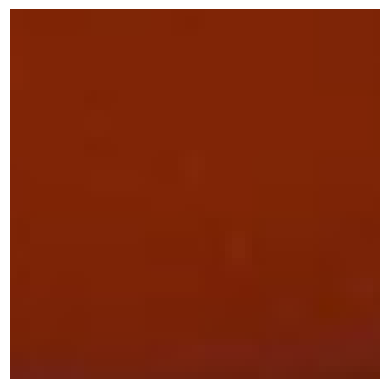

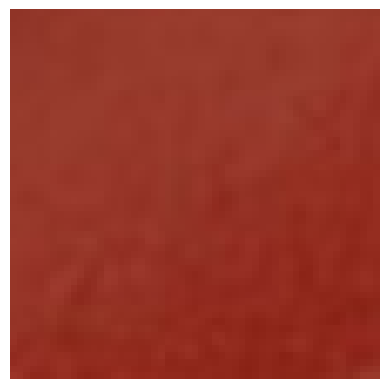

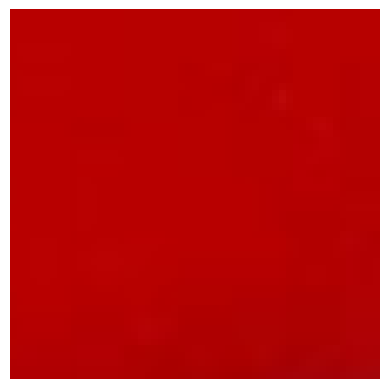

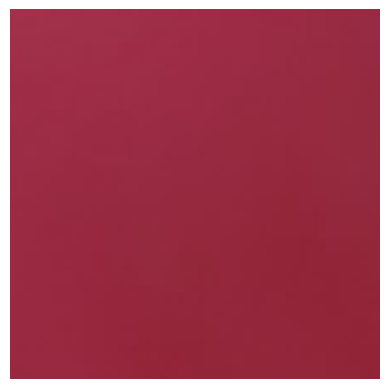

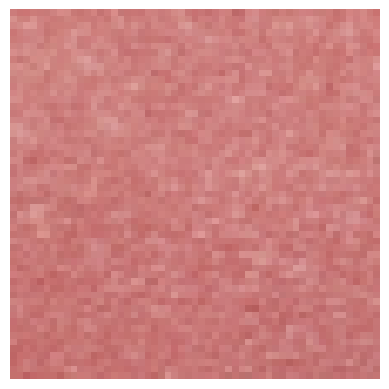

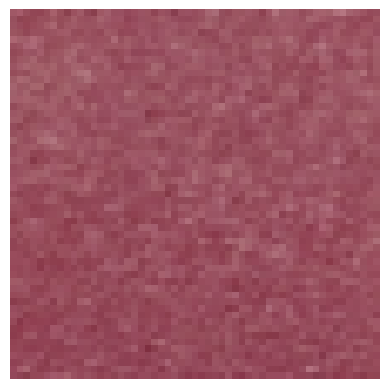

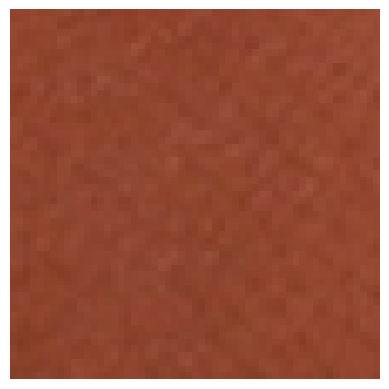

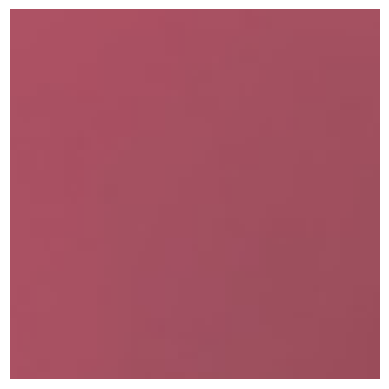

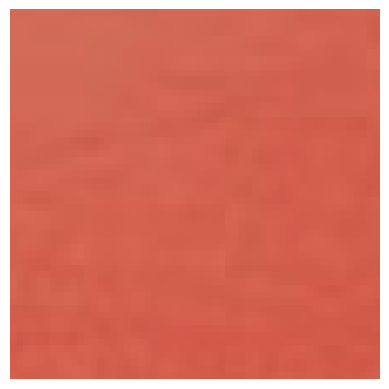

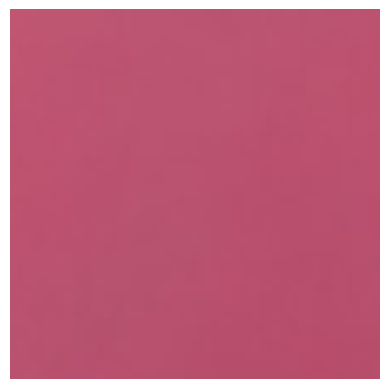

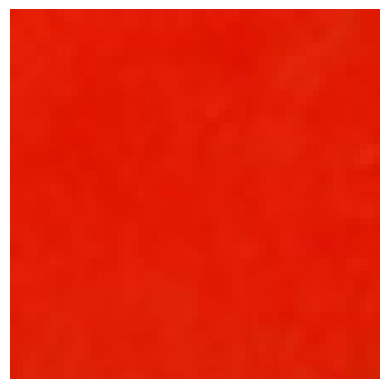

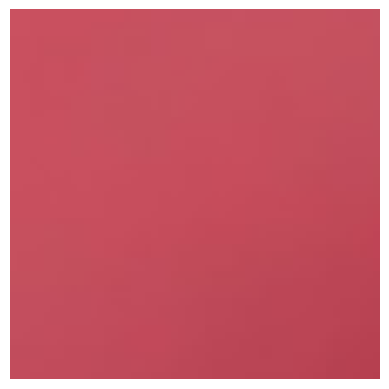

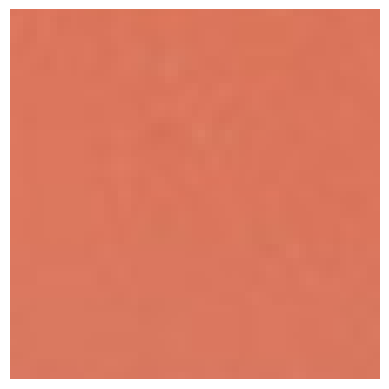

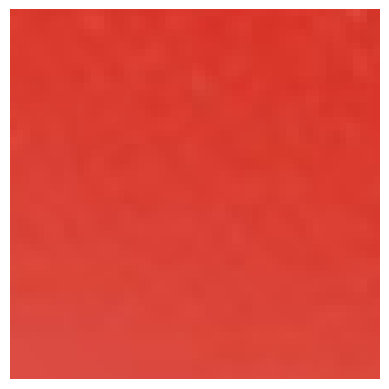

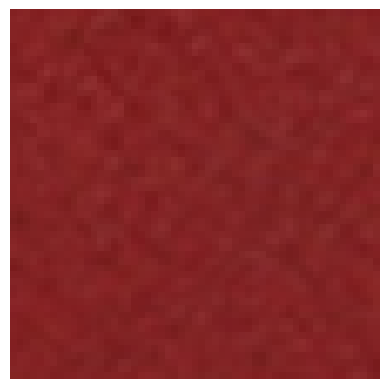

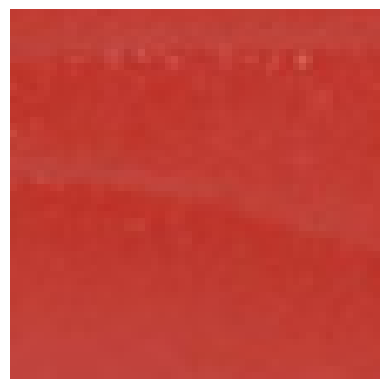

KeyboardInterrupt: 

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# 폴더 내의 모든 이미지 파일 불러오기
files = os.listdir(folder_path)

# 이미지 파일들을 순서대로 불러와 처리
for file in files:
    # 이미지 파일 경로 생성
    img_path = os.path.join(folder_path, file)

    # 이미지 불러오기
    image = Image.open(img_path)

    # 이미지 플로팅
    plt.imshow(image)
    plt.axis('off')  # 이미지 축 제거
    plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# 명도 계산 함수
def calculate_brightness(image):
    # 이미지를 그레이스케일로 변환
    grayscale_image = image.convert('L')
    # 이미지를 NumPy 배열로 변환
    grayscale_array = np.array(grayscale_image)
    # 이미지의 평균 픽셀 값을 1.5에서 9.5 사이의 값으로 정규화하여 명도로 간주
    normalized_brightness = ((np.mean(grayscale_array) - 0) / 255) * 8 + 1.5
    return normalized_brightness

# 이미지 파일이 있는 폴더 경로
folder_path = '/content/drive/MyDrive/oliveyoung_lip_color'

# 폴더 내의 모든 이미지 파일 불러오기
files = os.listdir(folder_path)

# 결과를 저장할 리스트 초기화
results = []

# 이미지 파일들을 순서대로 불러와 처리
for file in files:
    # 이미지 파일 경로 생성
    img_path = os.path.join(folder_path, file)

    # 이미지 불러오기
    image = Image.open(img_path)

    # 명도 계산
    brightness = calculate_brightness(image)

    # 결과 추가 (파일 이름과 명도 단계)
    results.append({'이미지 파일': file, 'PCCS 명도 단계': round(brightness, 1)})  # 소수점 첫째 자리까지 반올림

# 결과를 DataFrame으로 변환
df = pd.DataFrame(results)

# DataFrame을 엑셀 파일로 저장
excel_path = "result.xlsx"
df.to_excel(excel_path, index=False)

print("엑셀 파일이 저장되었습니다:", excel_path)


엑셀 파일이 저장되었습니다: result.xlsx


**HEX 코드로 HSV 값 얻기**

In [13]:
pip install pandas openpyxl

In [15]:
import pandas as pd
import colorsys

# CSV 파일 경로
csv_file = '/content/drive/MyDrive/converted_colors.csv'

# CSV 파일에서 데이터 읽기
df = pd.read_csv(csv_file)

In [16]:
# RGB 값을 HSV로 변환하여 채도(Saturation) 값만 추출하여 저장
def rgb_to_hsv(row):
    r, g, b = row['Red'], row['Green'], row['Blue']
    h, s, v = colorsys.rgb_to_hsv(r / 255.0, g / 255.0, b / 255.0)
    return round(s * 100, 0)

# RGB 컬럼의 값을 HSV로 변환하여 채도(Saturation) 값만 추출
df['Saturation'] = df.apply(rgb_to_hsv, axis=1)

# 채도 값만을 담은 새로운 CSV 파일로 저장
df[['File Name', 'Saturation']].to_csv('saturation.csv', index=False)

In [17]:
def rgb_to_hsv_custom(r, g, b):
    rgb = (r / 255.0, g / 255.0, b / 255.0)  # Normalize RGB values to [0, 1]
    hsv = rgb_to_hsv(rgb)
    return hsv

In [18]:
# HSV 값으로 변환한 결과를 새로운 컬럼에 추가
df[['H', 'S', 'V']] = df.apply(lambda row: pd.Series(rgb_to_hsv_custom(row['Red'], row['Green'], row['Blue'])), axis=1)

# 결과를 새로운 CSV 파일로 저장
df.to_csv('HSV.csv', index=False)


TypeError: tuple indices must be integers or slices, not str

In [ ]:
import pandas as pd

# CSV 파일 경로
input_csv_file = '/content/drive/MyDrive/HSV.csv'

# CSV 파일에서 데이터 읽기
df = pd.read_csv(input_csv_file)

# H 열의 값을 소수점 셋째 자리에서 반올림하고 *100을 해서 새로운 열에 저장
df['H_rounded'] = (df['H'] * 100).round(2)

# 결과를 새로운 CSV 파일로 저장
df.to_csv('HSV_new.csv', index=False)

**HSL**


In [19]:
import pandas as pd
import colorsys

# CSV 파일 경로
input_csv_file = '/content/drive/MyDrive/converted_colors.csv'

# CSV 파일에서 데이터 읽기
df = pd.read_csv(input_csv_file)


In [20]:
# RGB 값을 HSL로 변환하는 함수
def rgb_to_hsl(r, g, b):
    # RGB 값을 0-1 범위로 정규화
    r /= 255.0
    g /= 255.0
    b /= 255.0

    # colorsys 모듈을 사용하여 HSL로 변환
    h, l, s = colorsys.rgb_to_hls(r, g, b)

    # HSL 값 반환
    return h * 360, s * 100, l * 100

In [21]:
# RGB 열에서 RGB 값을 읽어와 HSL로 변환하여 새로운 열에 추가
df[['H', 'S', 'L']] = df.apply(lambda row: pd.Series(rgb_to_hsl(row['Red'], row['Green'], row['Blue'])), axis=1)

# 결과를 새로운 Excel 파일로 저장
df.to_csv('HSL.csv', index=False)